In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import json
import re
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap

DRIVE_ROOT = Path("/content/drive/MyDrive/semantic-drift")

NGRAM_DIR = DRIVE_ROOT / "ngram_data" / "data"
NGRAM_RESULTS_DIR = NGRAM_DIR / "results"

REDDIT_PROC_ROOT = DRIVE_ROOT / "reddit_data" / "processed"
MONTHLY_ROOT = REDDIT_PROC_ROOT / "monthly"

RESULTS_ROOT = DRIVE_ROOT / "data" / "results" / "old_vs_new"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_SUBREDDITS = [
    "Decadeology",
    "GenAlpha",
    "GenZ",
    "Youtube",
]

In [ ]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def stream_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except Exception:
                continue

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
def load_ngram_word(word):
    path = NGRAM_RESULTS_DIR / f"ngram_{word}.csv"
    if not path.exists():
        print("Missing Ngram file:", path)
        return pd.DataFrame()
    return pd.read_csv(path)

In [ ]:
def extract_contexts_across_subreddits(word, max_contexts_per_subreddit=1000):
    word = word.lower().strip()
    pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

    rows = []

    for subreddit in TARGET_SUBREDDITS:
        sub_dir = MONTHLY_ROOT / subreddit
        if not sub_dir.exists():
            continue

        sub_count = 0

        for file_path in sorted(sub_dir.glob("*.jsonl")):
            month = file_path.stem

            for obj in stream_jsonl(file_path):
                text = clean_text(obj.get("text", ""))
                if not text:
                    continue

                if pattern.search(text):
                    rows.append({
                        "word": word,
                        "subreddit": subreddit,
                        "month": month,
                        "text": text
                    })
                    sub_count += 1

                    if sub_count >= max_contexts_per_subreddit:
                        break

            if sub_count >= max_contexts_per_subreddit:
                break

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["month", "subreddit"]).reset_index(drop=True)
    return df

In [ ]:
def filter_cloud_contexts(df):
    positive = [
        r"\bmouse\b",
        r"\bcomputer mouse\b",
        r"\bmouse click\b",
        r"\bscroll\b",
        r"\bcursor\b",
        r"\btrackpad\b"
    ]

    negative = [
        r"\bmouse trap\b",
        r"\bmouse hole\b",
        r"\bmouse ran\b",
        r"\brodent\b"
    ]

    out = df.copy()
    mask = np.ones(len(out), dtype=bool)

    for pat in bad_patterns:
        mask &= ~out["text"].str.contains(pat, case=False, regex=True, na=False)

    return out[mask].reset_index(drop=True)

In [ ]:
MEANING_PROTOTYPES = {
    "cloud": {
        "old_source": "historical books / Ngram-era usage",
        "new_source": "modern Reddit-era usage",
        "old": [
            "Dark clouds filled the sky before the storm.",
            "The weather forecast predicted heavy clouds and rain.",
            "A white cloud drifted across the blue sky.",
            "Thunderclouds formed above the hills."
        ],
        "new": [
            "The company moved its servers to the cloud.",
            "Cloud computing powers modern web applications.",
            "Data is stored on cloud infrastructure.",
            "The platform uses cloud storage and cloud services."
        ]
    },
    "mouse": {
        "old_source": "historical books / animal meaning",
        "new_source": "modern computing usage",
        "old": [
            "The mouse ran across the kitchen floor.",
            "A small mouse hid behind the wall.",
            "The cat chased the mouse.",
            "The farmer saw a mouse in the barn."
        ],
        "new": [
            "Click the icon with the mouse.",
            "The wireless mouse stopped working.",
            "He moved the cursor using the mouse.",
            "I bought a new gaming mouse."
        ]
    },
    "tablet": {
        "old_source": "historical medicine / stone meaning",
        "new_source": "modern device usage",
        "old": [
            "The doctor prescribed a tablet for pain relief.",
            "She took the medicine tablet after dinner.",
            "The inscription was carved into a stone tablet.",
            "The ancient tablet contained writing."
        ],
        "new": [
            "She watched videos on her tablet.",
            "The tablet has a touchscreen display.",
            "He bought a new Android tablet.",
            "The app runs on both phone and tablet."
        ]
    },
    "viral": {
        "old_source": "historical disease meaning",
        "new_source": "modern internet meaning",
        "old": [
            "The disease spread through a viral infection.",
            "Doctors studied the viral outbreak carefully.",
            "The patient showed signs of viral disease.",
            "The illness was caused by a viral agent."
        ],
        "new": [
            "The video went viral on social media.",
            "The meme became viral overnight.",
            "The post went viral across the internet.",
            "The clip spread virally online."
        ]
    },
    "stream": {
        "old_source": "historical water meaning",
        "new_source": "modern media meaning",
        "old": [
            "A clear stream flowed through the forest.",
            "They sat beside the mountain stream.",
            "The stream ran gently over the rocks.",
            "Children played near the stream."
        ],
        "new": [
            "I stream music every day online.",
            "The game was streamed live to viewers.",
            "They stream videos on the platform.",
            "The creator started a livestream."
        ]
    },
    "troll": {
        "old_source": "historical folklore meaning",
        "new_source": "modern internet meaning",
        "old": [
            "The troll lived under the bridge in the story.",
            "Children heard tales about a forest troll.",
            "The giant troll guarded the cave.",
            "The fairy tale described an ugly troll."
        ],
        "new": [
            "He was banned for trolling people online.",
            "The forum was full of internet trolls.",
            "She ignored the troll in the comments.",
            "They were trolling users on social media."
        ]
    }
}

In [ ]:
def build_meaning_prototypes(word, model):
    if word not in MEANING_PROTOTYPES:
        raise ValueError(f"No meaning prototypes defined for '{word}'.")

    old_texts = MEANING_PROTOTYPES[word]["old"]
    new_texts = MEANING_PROTOTYPES[word]["new"]

    old_emb = model.encode(old_texts, show_progress_bar=False)
    new_emb = model.encode(new_texts, show_progress_bar=False)

    old_centroid = old_emb.mean(axis=0)
    new_centroid = new_emb.mean(axis=0)

    return old_centroid, new_centroid

In [ ]:
def assign_old_new_meanings(context_df, word, model, margin_threshold=0.03):
    if context_df.empty:
        out = context_df.copy()
        out["meaning_cluster"] = []
        out["sim_old"] = []
        out["sim_new"] = []
        out["confidence_margin"] = []
        return out

    old_centroid, new_centroid = build_meaning_prototypes(word, model)

    texts = context_df["text"].tolist()
    text_emb = model.encode(texts, batch_size=64, show_progress_bar=True)

    sim_old = cosine_similarity(text_emb, old_centroid.reshape(1, -1)).flatten()
    sim_new = cosine_similarity(text_emb, new_centroid.reshape(1, -1)).flatten()

    labels = []
    margins = []

    for so, sn in zip(sim_old, sim_new):
        margin = abs(so - sn)
        margins.append(float(margin))

        if margin < margin_threshold:
            labels.append("ambiguous")
        elif so > sn:
            labels.append("old_meaning")
        else:
            labels.append("new_meaning")

    out = context_df.copy()
    out["sim_old"] = sim_old
    out["sim_new"] = sim_new
    out["confidence_margin"] = margins
    out["meaning_cluster"] = labels

    return out

In [ ]:
def summarize_old_new(assigned_df):
    summary = assigned_df["meaning_cluster"].value_counts(dropna=False).to_dict()

    total = len(assigned_df)
    old_count = summary.get("old_meaning", 0)
    new_count = summary.get("new_meaning", 0)
    ambiguous_count = summary.get("ambiguous", 0)

    return {
        "total_contexts": total,
        "old_meaning_count": old_count,
        "new_meaning_count": new_count,
        "ambiguous_count": ambiguous_count,
        "old_meaning_ratio": old_count / total if total else 0,
        "new_meaning_ratio": new_count / total if total else 0,
        "ambiguous_ratio": ambiguous_count / total if total else 0,
    }

In [ ]:
def show_meaning_examples(assigned_df, n=8):
    for label in ["old_meaning", "new_meaning", "ambiguous"]:
        print("\n" + "=" * 80)
        print(label.upper())
        print("=" * 80)

        examples = (
            assigned_df[assigned_df["meaning_cluster"] == label]["text"]
            .drop_duplicates()
            .head(n)
            .tolist()
        )

        if not examples:
            print("No examples.")
            continue

        for e in examples:
            print("-", e)

In [ ]:
def plot_old_vs_new_meanings(assigned_df, model, word, save_fig=True):
    plot_df = assigned_df[assigned_df["meaning_cluster"] != "ambiguous"].copy()

    if plot_df.empty:
        print("No confident old/new assignments to plot.")
        return

    emb = model.encode(plot_df["text"].tolist(), batch_size=64, show_progress_bar=False)

    reducer = umap.UMAP(n_components=2, random_state=42)
    coords = reducer.fit_transform(emb)

    labels = plot_df["meaning_cluster"].values
    old_mask = labels == "old_meaning"
    new_mask = labels == "new_meaning"

    plt.figure(figsize=(10, 6))
    plt.scatter(coords[old_mask, 0], coords[old_mask, 1], s=28, alpha=0.75, label="Old meaning")
    plt.scatter(coords[new_mask, 0], coords[new_mask, 1], s=28, alpha=0.75, label="New meaning")
    plt.title(f"Old vs New meanings for '{word}'")
    plt.xlabel("Semantic Dimension 1")
    plt.ylabel("Semantic Dimension 2")
    plt.legend()
    plt.tight_layout()

    if save_fig:
        out_path = RESULTS_ROOT / f"{word}_old_vs_new_meanings.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()
    plt.close()

In [ ]:
def build_old_new_explanation(word, summary, ngram_df):
    lines = []

    lines.append(f'Word analyzed: "{word}".')

    if ngram_df is not None and not ngram_df.empty:
        nonzero = ngram_df[ngram_df["count"] > 0]
        first_year = int(nonzero["year"].min()) if not nonzero.empty else None
        peak_year = int(ngram_df.loc[ngram_df["count"].idxmax(), "year"])
        lines.append(
            f"In Google Books, the word appears historically from around {first_year} and reaches a peak near {peak_year}."
        )

    lines.append(f"Total Reddit contexts analyzed: {summary['total_contexts']}.")
    lines.append(f"Old meaning assignments: {summary['old_meaning_count']} ({summary['old_meaning_ratio']:.1%}).")
    lines.append(f"New meaning assignments: {summary['new_meaning_count']} ({summary['new_meaning_ratio']:.1%}).")
    lines.append(f"Ambiguous contexts: {summary['ambiguous_count']} ({summary['ambiguous_ratio']:.1%}).")

    if summary["new_meaning_ratio"] > 0.6:
        lines.append("Reddit usage is dominated by the newer meaning.")
    elif summary["old_meaning_ratio"] > 0.6:
        lines.append("Reddit usage is dominated by the older historical meaning.")
    elif summary["old_meaning_ratio"] > 0.2 and summary["new_meaning_ratio"] > 0.2:
        lines.append("Both meanings are present, suggesting semantic coexistence or transition.")
    else:
        lines.append("The evidence is mixed and should be interpreted cautiously.")

    return "\n".join(lines)

In [ ]:
def analyze_word_old_vs_new(word, max_contexts_per_subreddit=1000, margin_threshold=0.03):
    word = word.lower().strip()
    print(f"\nAnalyzing word with historical-old vs Reddit-new model: {word}\n")

    if word not in MEANING_PROTOTYPES:
        raise ValueError(f"No prototype meanings defined for '{word}'.")

    ngram_df = load_ngram_word(word)

    context_df = extract_contexts_across_subreddits(word, max_contexts_per_subreddit=max_contexts_per_subreddit)

    if context_df.empty:
        print(f"No Reddit contexts found for '{word}'.")
        return None

    if word == "cloud":
        context_df = filter_cloud_contexts(context_df)

    assigned_df = assign_old_new_meanings(
        context_df=context_df,
        word=word,
        model=embed_model,
        margin_threshold=margin_threshold
    )

    summary = summarize_old_new(assigned_df)

    explanation = build_old_new_explanation(word, summary, ngram_df)
    print(explanation)

    show_meaning_examples(assigned_df, n=8)
    plot_old_vs_new_meanings(assigned_df, embed_model, word)

    out_csv = RESULTS_ROOT / f"{word}_old_vs_new_assignments.csv"
    assigned_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    return {
        "word": word,
        "ngram_df": ngram_df,
        "assigned_df": assigned_df,
        "summary": summary,
        "explanation": explanation
    }


Analyzing word with historical-old vs Reddit-new model: cloud



Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Word analyzed: "cloud".
In Google Books, the word appears historically from around 1800 and reaches a peak near 2008.
Total Reddit contexts analyzed: 2028.
Old meaning assignments: 665 (32.8%).
New meaning assignments: 1143 (56.4%).
Ambiguous contexts: 220 (10.8%).
Both meanings are present, suggesting semantic coexistence or transition.

OLD_MEANING
- yes. that's the beauty of the cloud
- cry when it evaporates into a cloud of 1's and 0's.
- in kansas city on twc, was having issues with a video of a static image of a cloud with thunderstorm white noise when i woke up (stopping and starting every few seconds) it suggested it was likely a problem with my "choice of isp"...maybe it detects the unused google fiber box they installed in my apartment...
- well considering i paid almost $400cad for my licence, if i suddenly had problems with rendering, i'd be on the horn to magix so fast it would create an inter-dimensional time vortex within which i might get a chance to shake my younger se

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/cloud_old_vs_new_meanings.png


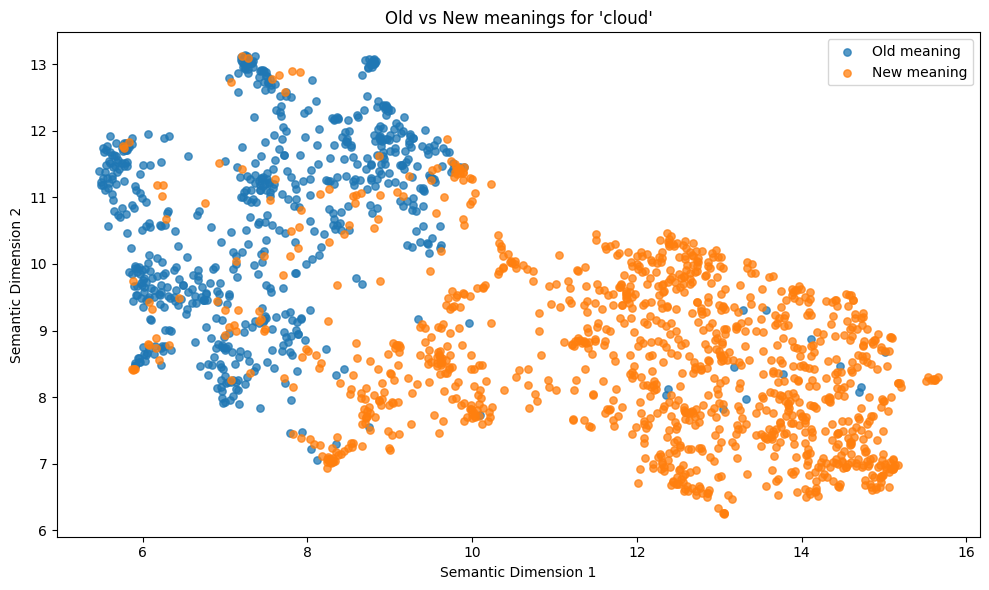

Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/cloud_old_vs_new_assignments.csv


In [ ]:
result = analyze_word_old_vs_new("cloud", max_contexts_per_subreddit=1000, margin_threshold=0.03)


Analyzing word with historical-old vs Reddit-new model: stream



Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Word analyzed: "stream".
In Google Books, the word appears historically from around 1800 and reaches a peak near 2008.
Total Reddit contexts analyzed: 2994.
Old meaning assignments: 196 (6.5%).
New meaning assignments: 2623 (87.6%).
Ambiguous contexts: 175 (5.8%).
Reddit usage is dominated by the newer meaning.

OLD_MEANING
- {"cpn":"im0knwsw9hgnpt89","vct":"1599.594","vd":"1690.901","vpl":"1072.876-1599.594,","vbu":"1134.933-1636.441,","vpa":false,"vsk":false,"ven":false,"vpr":1,"vrs":4,"vns":2,"vec":null,"vvol":1,"lct":"1599.525","lsk":false,"lmf":false,"lbw":"283472.369","lhd":"0.294","ltd":"334.556","laa":"itag=251,seg=163,range=27351667-27432851,time=1631.5-1636.5","lva":"itag=244,seg=322,range=122309339-122398562,time=1631.5-1636.5","lar":"itag=251,seg=164,range=27488445-27639950,time=1640.0-1650.0","lvr":"itag=244,seg=331,range=124265704-124437745,time=1677.1-1682.1","lvh":"r6---sn-q4fl6n7e","lab":"1060.001-1636.441,","lvb":"1134.933-1636.532,","state":"8","ismb":5820000,"debug_

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/stream_old_vs_new_meanings.png


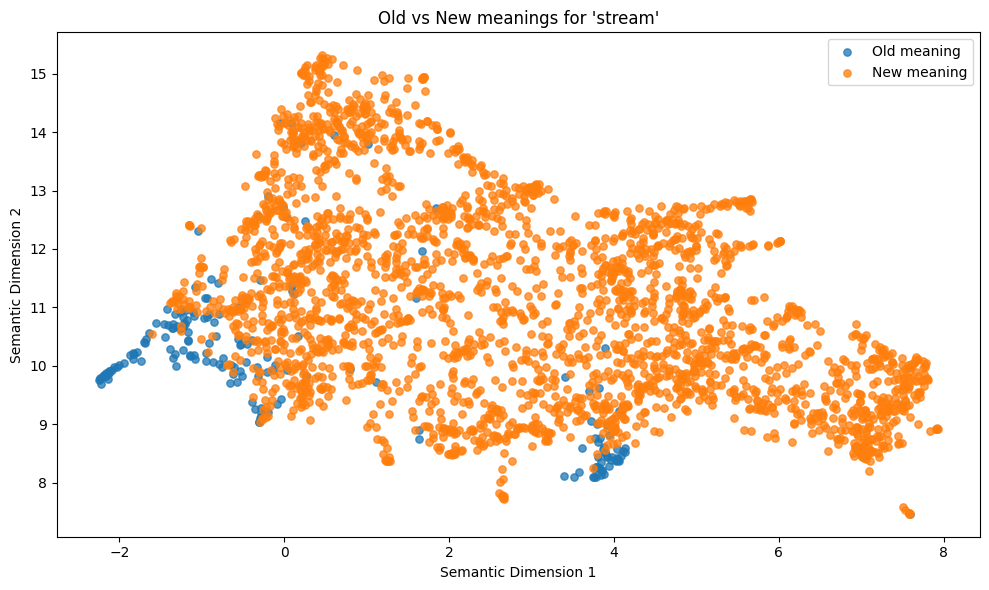

Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/stream_old_vs_new_assignments.csv


In [ ]:
result = analyze_word_old_vs_new("stream", max_contexts_per_subreddit=1000, margin_threshold=0.03)


Analyzing word with historical-old vs Reddit-new model: mouse



Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Word analyzed: "mouse".
In Google Books, the word appears historically from around 1800 and reaches a peak near 2004.
Total Reddit contexts analyzed: 2872.
Old meaning assignments: 924 (32.2%).
New meaning assignments: 1295 (45.1%).
Ambiguous contexts: 653 (22.7%).
Both meanings are present, suggesting semantic coexistence or transition.

OLD_MEANING
- 2 people ate brownies and the crums got into the mouse disturbing its stability, and ultimately leading the the wrong button being pressed. later the crums were eaten by ants.
- okay, i explained that poorly. what happens in almost every case of the ad blocker-blocker is that where the video is supposed to be appears a still image that lasts 30-60 seconds that reads something along the lines of "you aren't supporting our content creators/producers/site managers/etc. please turn off ad-blocker on our page and this staller will be removed" and no, that system would **not** fail. go to rooster teeth's website and watch a few videos and see 

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/mouse_old_vs_new_meanings.png


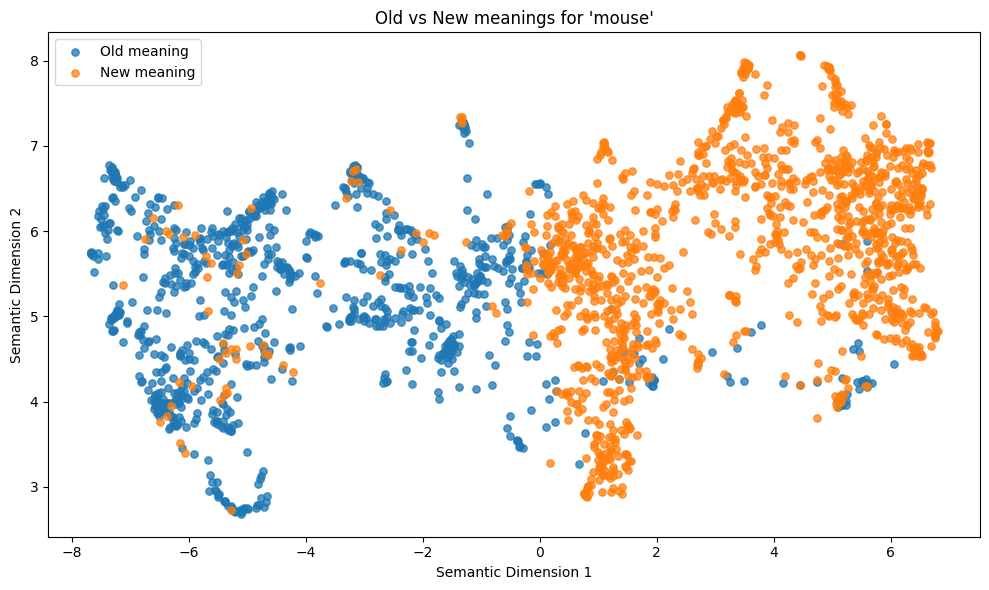

Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/mouse_old_vs_new_assignments.csv


In [ ]:
result = analyze_word_old_vs_new("mouse", max_contexts_per_subreddit=1000, margin_threshold=0.03)


Analyzing word with historical-old vs Reddit-new model: tablet



Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Word analyzed: "tablet".
In Google Books, the word appears historically from around 1800 and reaches a peak near 2008.
Total Reddit contexts analyzed: 2927.
Old meaning assignments: 53 (1.8%).
New meaning assignments: 2792 (95.4%).
Ambiguous contexts: 82 (2.8%).
Reddit usage is dominated by the newer meaning.

OLD_MEANING
- # *online book "poems of alfred lord tennyson by alfred lord tennyson" windows download thepiratebay pdf german wiki* *** ## █ ► [**read** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** *** ## █ ► [**online** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** *** ## █ ► [**download** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** . *** ## █ ► [**read** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** *** ## █ ► [**online** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** *** ## █ ► [**download** ***poems of alfred lord tennyson by alfred lord tennyson***]( *** > . > description bo

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/tablet_old_vs_new_meanings.png


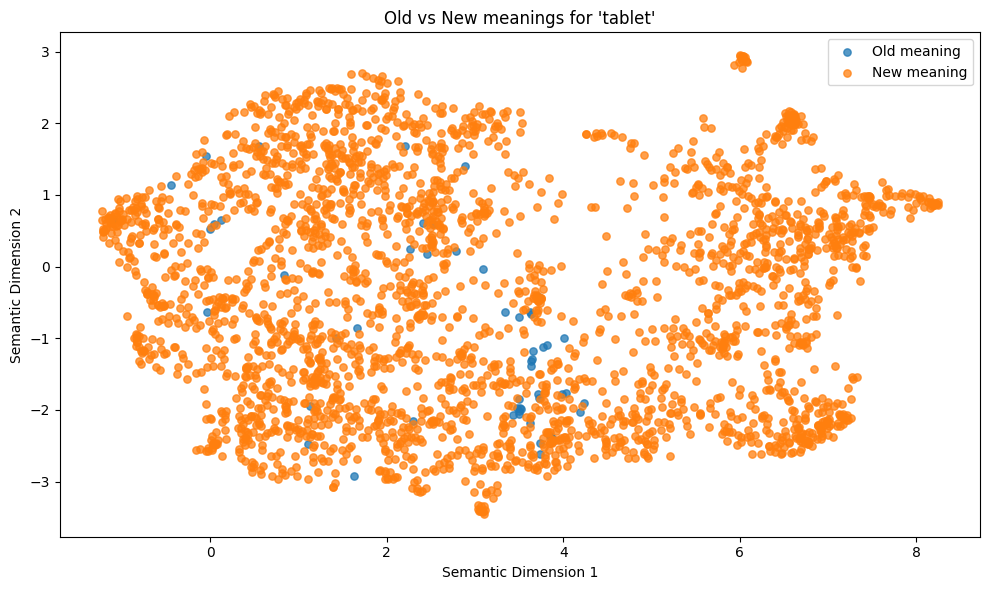

Saved: /content/drive/MyDrive/semantic-drift/data/results/old_vs_new/tablet_old_vs_new_assignments.csv


In [ ]:
result = analyze_word_old_vs_new("tablet", max_contexts_per_subreddit=1000, margin_threshold=0.03)